<a href="https://colab.research.google.com/github/Victor-Tung/CS171_news_classification/blob/main/CS171_news_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# Data Investigation


In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Read the features file.
train_data = pd.read_csv('/content/drive/MyDrive/CS171/ag_train.csv',header=None,
                   names=['class', 'title', 'description'])
test_data = pd.read_csv('/content/drive/MyDrive/CS171/ag_test.csv',header=None,
                   names=['class', 'title', 'description'])
#first 30 lines are all class index 3, data set is well balanced
print(train_data['class'].value_counts().sort_index())
print('-----------------------------------')
train_data.tail(5)


class
1              30000
2              30000
3              30000
4              30000
Class Index        1
Name: count, dtype: int64
-----------------------------------


,class,title,description
119996,1,Pakistan's Musharraf Says Won't Quit as Army Chief,"KARACHI (Reuters) - Pakistani President Pervez Musharraf has said he will stay on as army chief, reneging on a pledge to quit the powerful post by the end of the year."
119997,2,Renteria signing a top-shelf deal,"Red Sox general manager Theo Epstein acknowledged Edgar Renteria was more a luxury for the 2005 Red Sox than a necessity. But there's nothing wrong with getting the keys to a BMW, and that's what the four-time All-Star and two-time Gold Glover is in the eyes of the Red Sox."
119998,2,Saban not going to Dolphins yet,"The Miami Dolphins will put their courtship of LSU coach Nick Saban on hold to comply with the NFL's hiring policy by interviewing at least one minority candidate, a team source told The Associated Press last night."
119999,2,Today's NFL games,"PITTSBURGH at NY GIANTS Time: 1:30 p.m. Line: Steelers by 10. Records: Steelers 12-1, Giants 5-8. Vs. spread: Steelers 10-1-2, Giants 5-8. Series: Giants lead, 43-27-3. Comments: Think the Giants knew Ben Roethlisberger was available on draft day when they broke the bank and traded for Eli Manning? . . . All Big Ben has done this year is complete ..."
120000,2,Nets get Carter from Raptors,"INDIANAPOLIS -- All-Star Vince Carter was traded by the Toronto Raptors to the New Jersey Nets for Alonzo Mourning, Eric Williams, Aaron Williams, and a pair of first-round draft picks yesterday."


In [ ]:
train_data.shape

(120001, 3)

In [ ]:
train_data.columns

Index(['class', 'title', 'description'], dtype='object')

In [ ]:
train_data.dtypes

,0
class,object
title,object
description,object


# Data Preprocessing and Cleaning


In [ ]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)        # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()          # collapse extra whitespace
    text = ' '.join([w for w in text.split() if w not in stop_words])  # remove stopwords
    return text

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
train_data['title_clean'] = train_data['title'].apply(clean_text)
train_data['description_clean'] = train_data['description'].apply(clean_text)
train_data['text'] = train_data['title_clean'] + ' ' + train_data['description_clean']

In [ ]:
test_data['title_clean'] = test_data['title'].apply(clean_text)
test_data['description_clean'] = test_data['description'].apply(clean_text)
test_data['text'] = test_data['title_clean'] + ' ' + test_data['description_clean']

In [ ]:
# testing clean function
test_val = 5000
print("BEFORE:", train_data['title'].iloc[test_val])
print("AFTER: ", train_data['title_clean'].iloc[test_val])
print()
print("BEFORE:", train_data['description'].iloc[test_val])
print("AFTER: ", train_data['description_clean'].iloc[test_val])
train_data.head(5)

BEFORE: General Growth Properties to acquire Rouse for \$12.6 bn
AFTER:  general growth properties acquire rouse 12 6 bn

BEFORE: NEW YORK, August 20 (New Ratings)  General Growth Properties Inc (GGP.NYS), the second-largest shopping mall operator in the US, has agreed to buy Rouse Company (RSE), in a cash and debt assumptions deal worth about \$12.6 billion. 
AFTER:  new york august 20 new ratings general growth properties inc ggp nys second largest shopping mall operator us agreed buy rouse company rse cash debt assumptions deal worth 12 6 billion


,class,title,description,title_clean,description_clean,text
0,Class Index,Title,Description,title,description,title description
1,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.",wall st bears claw back black reuters,reuters short sellers wall street dwindling band ultra cynics seeing green,wall st bears claw back black reuters reuters short sellers wall street dwindling band ultra cynics seeing green
2,3,Carlyle Looks Toward Commercial Aerospace (Reuters),"Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.",carlyle looks toward commercial aerospace reuters,reuters private investment firm carlyle group reputation making well timed occasionally controversial plays defense industry quietly placed bets another part market,carlyle looks toward commercial aerospace reuters reuters private investment firm carlyle group reputation making well timed occasionally controversial plays defense industry quietly placed bets another part market
3,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums.,oil economy cloud stocks outlook reuters,reuters soaring crude prices plus worries economy outlook earnings expected hang stock market next week depth summer doldrums,oil economy cloud stocks outlook reuters reuters soaring crude prices plus worries economy outlook earnings expected hang stock market next week depth summer doldrums
4,3,Iraq Halts Oil Exports from Main Southern Pipeline (Reuters),"Reuters - Authorities have halted oil export\flows from the main pipeline in southern Iraq after\intelligence showed a rebel militia could strike\infrastructure, an oil official said on Saturday.",iraq halts oil exports main southern pipeline reuters,reuters authorities halted oil export flows main pipeline southern iraq intelligence showed rebel militia could strike infrastructure oil official said saturday,iraq halts oil exports main southern pipeline reuters reuters authorities halted oil export flows main pipeline southern iraq intelligence showed rebel militia could strike infrastructure oil official said saturday


# Building/Training Custom CNN


In [ ]:
train_data = train_data[train_data["class"] != "Class Index"].copy()
test_data = test_data[test_data["class"] != "Class Index"].copy()

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# Raw data
train_texts = train_data["text"].astype(str).values
train_labels = train_data["class"].astype(str).values  # keep as strings

test_texts = test_data["text"].astype(str).values
test_labels = test_data["class"].astype(str).values

# Map class IDs → names
class_names = {
    "1": "World",
    "2": "Sports",
    "3": "Business",
    "4": "Sci/Tech"
}

# Downsample training set
train_texts, _, train_labels, _ = train_test_split(
    train_texts,
    train_labels,
    train_size=50000,
    random_state=42,
    stratify=train_labels
)

# Encode labels ("1"–"4" → 0–3)
label_encoder = LabelEncoder()
y_train_int = label_encoder.fit_transform(train_labels)
y_test_int = label_encoder.transform(test_labels)

# One-hot encode
num_classes = len(label_encoder.classes_)
y_train = to_categorical(y_train_int, num_classes=num_classes)
y_test = to_categorical(y_test_int, num_classes=num_classes)

# Tokenizer
max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

X_train_seq = tokenizer.texts_to_sequences(train_texts)
X_test_seq = tokenizer.texts_to_sequences(test_texts)

X_train = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_test = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

print("LabelEncoder classes:", label_encoder.classes_)
print("Class mapping:", class_names)

LabelEncoder classes: ['1' '2' '3' '4']
Class mapping: {'1': 'World', '2': 'Sports', '3': 'Business', '4': 'Sci/Tech'}


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_5          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.4038 - loss: 1.3335 - val_accuracy: 0.7565 - val_loss: 1.1428
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7324 - loss: 0.8072 - val_accuracy: 0.8581 - val_loss: 0.5012
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8470 - loss: 0.5031 - val_accuracy: 0.8850 - val_loss: 0.3756
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8805 - loss: 0.4072 - val_accuracy: 0.8963 - val_loss: 0.3299
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8956 - loss: 0.3539 - val_accuracy: 0.9012 - val_loss: 0.3096
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9093 - loss: 0.3164 - val_accuracy: 0.9046 - val_loss: 0.2966
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9170 - loss: 0.2895 - val_accuracy: 0.9055 - val_loss: 0.2918
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9259 - loss: 0.2618 -

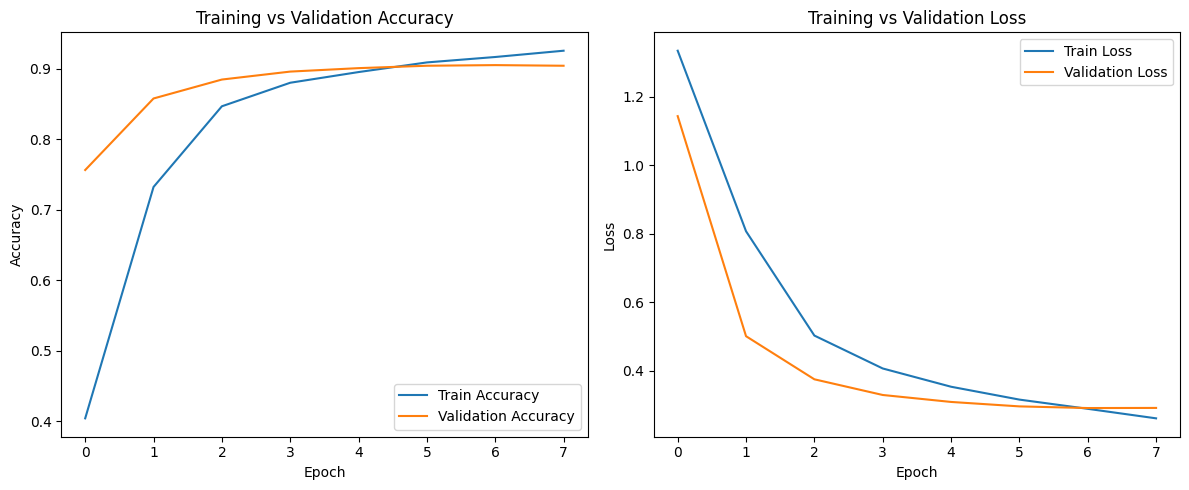

Test Loss: 0.3028
Test Accuracy: 0.9016
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Classification Report:

              precision    recall  f1-score   support

       World     0.9163    0.8984    0.9073      1900
      Sports     0.9462    0.9716    0.9587      1900
    Business     0.8669    0.8674    0.8671      1900
    Sci/Tech     0.8759    0.8689    0.8724      1900

    accuracy                         0.9016      7600
   macro avg     0.9013    0.9016    0.9014      7600
weighted avg     0.9013    0.9016    0.9014      7600


Confusion Matrix:

[[1707   58   76   59]
 [  28 1846   17    9]
 [  65   21 1648  166]
 [  63   26  160 1651]]


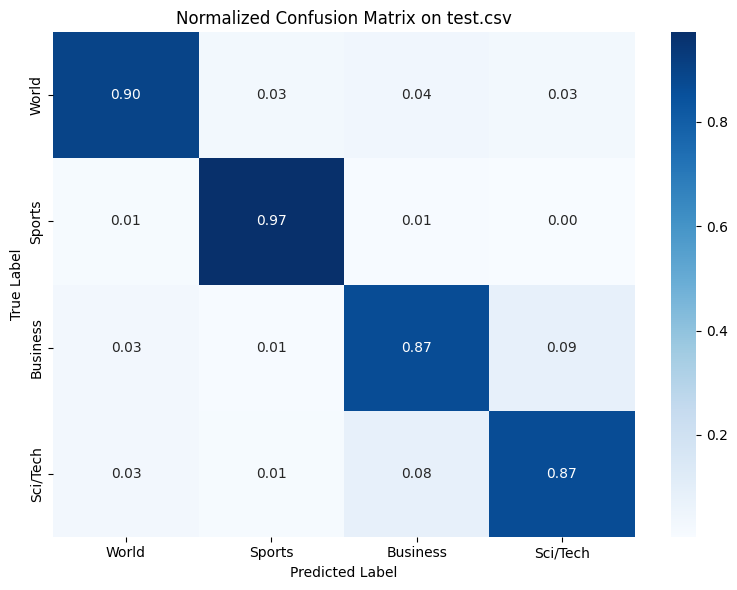

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout, SpatialDropout1D
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2


# embedding_dim = 128
# num_classes = y_train.shape[1]

model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim),
    Conv1D(filters=128, kernel_size=3, activation="relu"),
    GlobalMaxPooling1D(),
    Dropout(0.3),
    Dense(64, activation="relu",kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# Train only on train.csv
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=1,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

# Test only on test.csv
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Predictions on test.csv
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Convert encoded labels back to original IDs: "1", "2", "3", "4"
predicted_class_ids = label_encoder.inverse_transform(y_pred)
true_class_ids = label_encoder.inverse_transform(y_true)

# Convert IDs to readable class names
predicted_labels = [class_names[i] for i in predicted_class_ids]
true_labels = [class_names[i] for i in true_class_ids]

class_label_names = list(class_names.values())

print("\nClassification Report:\n")
print(classification_report(
    true_labels,
    predicted_labels,
    labels=class_label_names,
    digits=4
))

cm = confusion_matrix(
    true_labels,
    predicted_labels,
    labels=class_label_names
)

print("\nConfusion Matrix:\n")
print(cm)

cm_normalized = cm.astype("float") / np.maximum(cm.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_label_names,
    yticklabels=class_label_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix on test.csv")
plt.tight_layout()
plt.show()

# Fine-tuning DistilBERT

Install and Imports


In [ ]:
!pip install transformers accelerate -q

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset, Dataset
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, get_linear_schedule_with_warmup

from torch.optim import AdamW
from sklearn.metrics import classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

import pandas as pd
from sklearn.preprocessing import LabelEncoder

train_data = pd.read_csv('/content/drive/MyDrive/CS171/ag_train.csv', header=None,
                         names=['class', 'title', 'description'])
test_data  = pd.read_csv('/content/drive/MyDrive/CS171/ag_test.csv', header=None,
                         names=['class', 'title', 'description'])

train_data = train_data[train_data["class"] != "Class Index"].copy()
test_data  = test_data[test_data["class"] != "Class Index"].copy()

class_names = {"1": "World", "2": "Sports", "3": "Business", "4": "Sci/Tech"}
num_classes = 4

label_encoder = LabelEncoder()
label_encoder.fit(train_data["class"].astype(str).values)

Prepare Raw Text

In [ ]:
train_data_clean = train_data[train_data["class"] != "Class Index"].copy()
test_data_clean  = test_data[test_data["class"] != "Class Index"].copy()

distil_train_texts = (
    train_data_clean["title"].fillna("") + ". " + train_data_clean["description"].fillna("")
).astype(str).values

distil_test_texts = (
    test_data_clean["title"].fillna("") + ". " + test_data_clean["description"].fillna("")
).astype(str).values

from sklearn.model_selection import train_test_split

distil_train_texts, _, distil_train_labels, _ = train_test_split(
    distil_train_texts,
    train_data_clean["class"].astype(str).values,
    train_size=50000,
    random_state=42,
    stratify=train_data_clean["class"].astype(str).values
)

distil_test_labels = test_data_clean["class"].astype(str).values

distil_y_train_int = label_encoder.transform(distil_train_labels)
distil_y_test_int = label_encoder.transform(distil_test_labels)
print(f"Train: {len(distil_train_texts):,} | Test: {len(distil_test_texts):,}")

Tokenizer and Dataset

In [ ]:
DISTIL_MAX_LEN = 128
BATCH_SIZE = 32
EPOCHS = 3
LR = 2e-5

distil_tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

class AGNewsDataset(Dataset):
  def __init__(self, texts, labels, tokenizer, max_len):
    self.texts = list(texts)
    self.labels = list(labels)
    self.tokenizer = tokenizer
    self.max_len = max_len

  def __len__(self):
    return len(self.texts)
  def __getitem__(self, idx):
    enc = self.tokenizer(
        self.texts[idx],
        max_length = self.max_len,
        padding = "max_length",
        truncation = True,
        return_tensors = "pt"
    )
    return {
        "input_ids": enc["input_ids"].squeeze(0),
        "attention_mask": enc["attention_mask"].squeeze(0),
        "labels": torch.tensor(self.labels[idx], dtype=torch.long)
    }
train_dataset = AGNewsDataset(distil_train_texts, distil_y_train_int, distil_tokenizer, DISTIL_MAX_LEN)
test_dataset = AGNewsDataset(distil_test_texts, distil_y_test_int, distil_tokenizer, DISTIL_MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,num_workers=2, pin_memory=True)
print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")

Training

In [ ]:
distil_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_classes,
)
distil_model.to(device)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * 0.1)

optimizer = AdamW(distil_model.parameters(), lr=LR, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(distil_model)

In [ ]:
def train_epoch(model, loader, optimizer, scheduler):
  model.train()
  total_loss, correct, n = 0.0, 0, 0
  for step, batch in enumerate(loader):
    ids = batch["input_ids"].to(device)
    mask = batch["attention_mask"].to(device)
    labels = batch["labels"].to(device)

    optimizer.zero_grad()
    output = model(input_ids=ids, attention_mask=mask, labels=labels)
    output.loss.backward()
    optimizer.step()
    scheduler.step()

    preds = output.logits.argmax(dim=1)
    correct += (preds == labels).sum().item()
    total_loss += output.loss.item() * labels.size(0)
    n += labels.size(0)
    if (step + 1 ) % 100 == 0:
      print(f" step {step+1}/{len(loader)} | loss: {total_loss/n:.4f} | acc: {correct/n:.4f}")

  return total_loss / n, correct / n

def evaluate_epoch(model, loader):
  model.eval()
  total_loss, correct, n = 0.0, 0, 0
  with torch.no_grad():
    for batch in loader:
      ids = batch["input_ids"].to(device)
      mask = batch["attention_mask"].to(device)
      labels = batch["labels"].to(device)
      output = model(input_ids=ids, attention_mask=mask, labels=labels)
      preds = output.logits.argmax(dim=1)
      correct += (preds == labels).sum().item()
      total_loss += output.loss.item() * labels.size(0)
      n += labels.size(0)
  return total_loss / n, correct / n

distil_history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
  print(f"\n Epoch {epoch}/ {EPOCHS}")
  train_loss, train_acc = train_epoch(distil_model, train_loader, optimizer, scheduler)
  val_loss, val_acc = evaluate_epoch(distil_model, test_loader)
  distil_history["train_loss"].append(train_loss)
  distil_history["train_acc"].append(train_acc)
  distil_history["val_loss"].append(val_loss)
  distil_history["val_acc"].append(val_acc)
  print(f" Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}")
  print(f" Val loss: {val_loss:.4f} | Val acc: {val_acc:.4f}")

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(distil_history["train_acc"], label="Train Accuracy")
plt.plot(distil_history["val_acc"],   label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("DistilBERT – Training vs Validation Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(distil_history["train_loss"], label="Train Loss")
plt.plot(distil_history["val_loss"],   label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DistilBERT – Training vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
distil_model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for batch in test_loader:
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        out  = distil_model(input_ids=ids, attention_mask=mask)
        all_preds.extend(out.logits.argmax(dim=1).cpu().numpy())
        all_true.extend(batch["labels"].numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

test_acc_distil = (all_preds == all_true).mean()
print(f"Test Accuracy (DistilBERT): {test_acc_distil:.4f}")

predicted_class_ids = label_encoder.inverse_transform(all_preds)
true_class_ids      = label_encoder.inverse_transform(all_true)
predicted_labels    = [class_names[i] for i in predicted_class_ids]
true_labels_named   = [class_names[i] for i in true_class_ids]

class_label_names = list(class_names.values())

print("\nClassification Report:\n")
print(classification_report(
    true_labels_named,
    predicted_labels,
    labels=class_label_names,
    digits=4,
))

cm = confusion_matrix(true_labels_named, predicted_labels, labels=class_label_names)
cm_normalized = cm.astype("float") / np.maximum(cm.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_label_names,
    yticklabels=class_label_names,
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("DistilBERT – Normalized Confusion Matrix on test.csv")
plt.tight_layout()
plt.show()

# Compare/Constrast Results